# HOUSE PRICE PREDICTION

**GOAL**: Predict house prices based on features like size, location, number of rooms, etc.

**BUSINESS PROBLEM**:
A real estate company wants to automatically estimate house prices
to help agents and customers make informed decisions.

**SUCCESS METRICS**:
- RMSE < $30,000 (within 30k of actual price)
- R² > 0.85 (explain 85% of variance)
- Fast predictions (<1 second)

**CONSTRAINTS**:
- Incomplete Data (some features missing)
- Using Interpretable Model (for explaining to customers)

### Importing Dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import time
import os

import joblib

#### Creating Data

In [3]:
np.random.seed(42)
n_samples = 1000

# Generating Synthetic House Data
data = {
    'size_sqft': np.random.randint(500, 5000, n_samples),
    'bedrooms': np.random.randint(1, 6, n_samples),
    'bathrooms': np.random.randint(1, 4, n_samples),
    'age_years': np.random.randint(0, 50, n_samples),
    'garage': np.random.choice([0, 1, 2], n_samples),
    'location': np.random.choice(['urban', 'suburban', 'rural'], n_samples),
    'condition': np.random.choice(['poor', 'fair', 'good', 'excellent'], n_samples),
    'has_pool': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
    'has_garden': np.random.choice([0, 1], n_samples, p=[0.4, 0.6])
}

df = pd.DataFrame(data)

# Calculating Price
df['price'] = (
    df['size_sqft'] * 150 +  # Base price per sqft
    df['bedrooms'] * 10000 +
    df['bathrooms'] * 15000 -
    df['age_years'] * 500 +
    df['garage'] * 20000 +
    df['has_pool'] * 30000 +
    df['has_garden'] * 15000 +
    np.random.normal(0, 30000, n_samples)  # Noise
)

# Adding location multiplier
location_mult = {'urban': 1.3, 'suburban': 1.0, 'rural': 0.8}
df['price'] *= df['location'].map(location_mult)

# Adding Condition Multiplier
condition_mult = {'poor': 0.8, 'fair': 0.9, 'good': 1.0, 'excellent': 1.2}
df['price'] *= df['condition'].map(condition_mult)

# Add some missing values (realistic scenario)
df.loc[np.random.choice(df.index, 50), 'garage'] = np.nan
df.loc[np.random.choice(df.index, 30), 'age_years'] = np.nan



# Saving Dataset
df.to_csv('house_prices.csv', index = False)

print(f'Dataset Created: {df.shape}')
print(f'\nFirst 5 Rows:')
print(df.head())

Dataset Created: (1000, 10)

First 5 Rows:
   size_sqft  bedrooms  bathrooms  age_years  garage  location  condition  \
0       1360         2          1       31.0     2.0  suburban  excellent   
1       4272         3          3        2.0     1.0  suburban       poor   
2       3592         1          2        2.0     1.0  suburban       good   
3        966         1          2       27.0     2.0  suburban       poor   
4       4926         2          1       43.0     2.0     urban       fair   

   has_pool  has_garden          price  
0         0           1  266060.561607  
1         1           1  631315.780611  
2         0           0  562167.042802  
3         0           1  171584.241939  
4         0           1  963414.207942  


#### Exploratory Data Analysis

In [4]:
df = pd.read_csv('house_prices.csv')
df.head()

,size_sqft,bedrooms,bathrooms,age_years,garage,location,condition,has_pool,has_garden,price
0,1360,2,1,31.0,2.0,suburban,excellent,0,1,266060.561607
1,4272,3,3,2.0,1.0,suburban,poor,1,1,631315.780611
2,3592,1,2,2.0,1.0,suburban,good,0,0,562167.042802
3,966,1,2,27.0,2.0,suburban,poor,0,1,171584.241939
4,4926,2,1,43.0,2.0,urban,fair,0,1,963414.207942


In [4]:
print(df.shape)
print(df.dtypes)

(1000, 10)
size_sqft       int64
bedrooms        int64
bathrooms       int64
age_years     float64
garage        float64
location       object
condition      object
has_pool        int64
has_garden      int64
price         float64
dtype: object


In [5]:
df.isna().sum()

size_sqft      0
bedrooms       0
bathrooms      0
age_years     29
garage        49
location       0
condition      0
has_pool       0
has_garden     0
price          0
dtype: int64

In [6]:
df.describe()

,size_sqft,bedrooms,bathrooms,age_years,garage,has_pool,has_garden,price
count,1000.000000,1000.000000,1000.000000,971.000000,951.000000,1000.00000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,24.795057,1.007361,0.29400,0.600000,5.010586e+05
std,1255.514921,1.427564,0.820332,14.454273,0.816248,0.45582,0.490143,2.277399e+05
min,503.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,8.548182e+04
25%,1749.500000,2.000000,1.000000,12.000000,0.000000,0.00000,0.000000,3.263034e+05
50%,2862.500000,3.000000,2.000000,25.000000,1.000000,0.00000,1.000000,4.838241e+05
75%,3849.500000,4.000000,3.000000,37.000000,2.000000,1.00000,1.000000,6.463380e+05
max,4999.000000,5.000000,3.000000,49.000000,2.000000,1.00000,1.000000,1.314534e+06


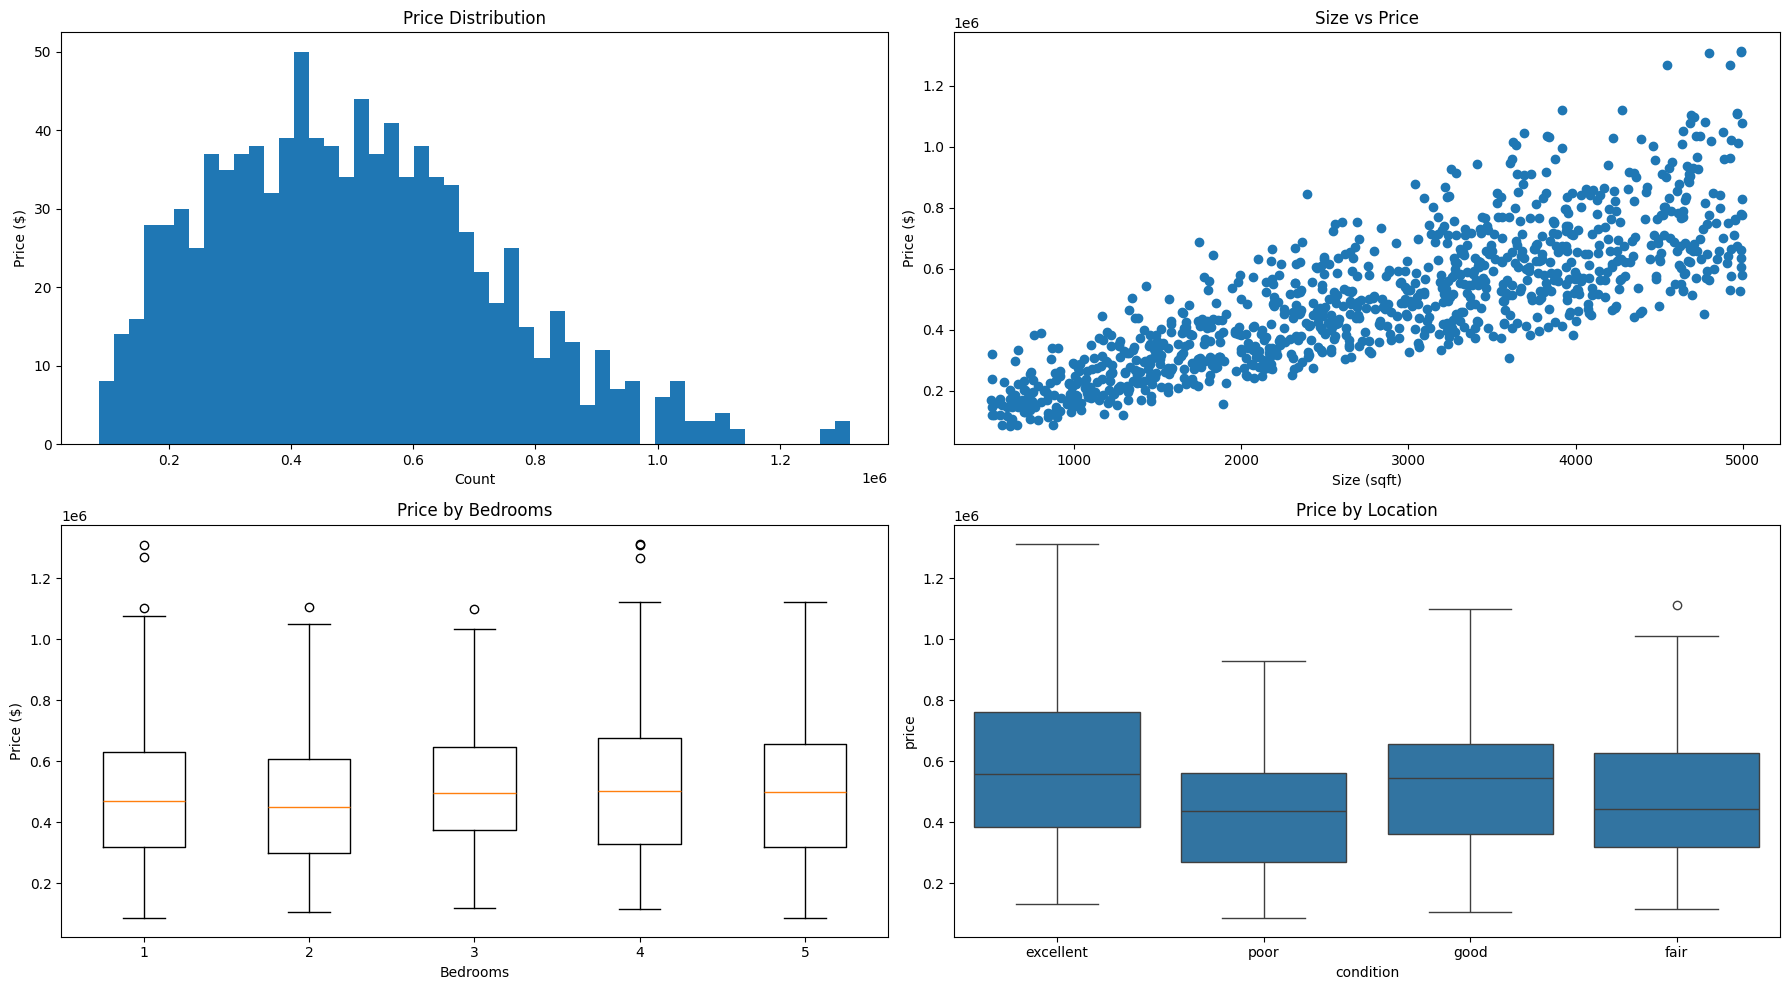

In [7]:
plt.figure(figsize = (18, 10))

# Price Dist
plt.subplot(2, 2, 1)
plt.hist(df['price'], bins = 50)
plt.xlabel('Count')
plt.ylabel('Price ($)')
plt.title('Price Distribution')

# Size vs Price
plt.subplot(2, 2, 2)
plt.scatter(x = df['size_sqft'], y = df['price'])
plt.xlabel('Size (sqft)')
plt.ylabel('Price ($)')
plt.title('Size vs Price')

# Bedroom vs Price
plt.subplot(2, 2, 3)
plt.boxplot([df[df['bedrooms'] == i]['price'] for i in range(1, 6)])
plt.xlabel('Bedrooms')
plt.ylabel('Price ($)')
plt.title('Price by Bedrooms')

# Location vs Price
plt.subplot(2, 2, 4)
sns.boxplot(data = df, x = 'condition', y = 'price')
plt.title('Price by Location')


plt.tight_layout()
plt.show()

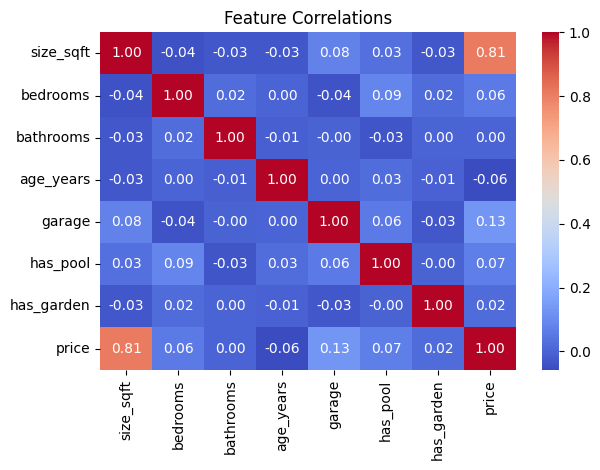

In [8]:
num_cols = df.select_dtypes(include = [np.number]).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations')


plt.tight_layout()
plt.show()

In [9]:
df.skew(numeric_only = True)

size_sqft    -0.066001
bedrooms      0.025884
bathrooms     0.049917
age_years    -0.025677
garage       -0.013533
has_pool      0.905677
has_garden   -0.408862
price         0.542146
dtype: float64

**Observations:**
- We have 9 features and 1 label and we have total 1000 rows of data.
- We have:
  - size_sqft, bedrooms, bathrooms, has_pool, has_garden  as int64 datatype.
  - age_years, garage, price as float64 datatype.
  - location, condition as object datatype.
- We have 29 values missing in age_years column and 49 values missing in garage column.
- The size_sqft and price are very highly correlated and garage and price are also somewhat correlated.
- Price Distribution shows a little right skewed data.

#### Data Preprocessing

In [10]:
X = df.drop('price', axis = 1)
y = df.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Price won't come in num_features because it is a Label.
num_features = ['size_sqft', 'bedrooms', 'bathrooms', 'has_pool', 'has_garden', 'age_years', 'garage']
cat_features = ['location', 'condition']

# Pipeline for Filling Missing Values and Scaling
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('ohe', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'))
])

# Putting together the pipeline and features
transformer = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
])

# Transforming the data
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

**Observation:**
* Here we split the data into training and test data.
* Then we separated the numerical and categorical features.
* We created pipelines for num and cat data to fill the missing data and to scale the data.
* We created a column_transformer to transform the num and cat features using those pipelines.
* We used that transformer to actually transform our training data.

#### Feature Engineering

In [11]:
from sklearn.preprocessing import FunctionTransformer

def create_features(X):
    X = X.copy()

    X['total_rooms'] = X['bedrooms'] + X['bathrooms']
    X['room_size'] = X['size_sqft'] / (X['total_rooms'] + 1)
    X['luxury_score'] = (X['has_pool'] + X['has_garden']) * X['size_sqft'] / 1000

    X['is_new'] = (X['age_years'] < 5).astype(int)
    X['is_old'] = (X['age_years'] > 30).astype(int)

    X['is_small'] = (X['size_sqft'] < 1500).astype(int)  # because our Q1 is 1750 (approx)
    X['is_large'] = (X['size_sqft'] > 3000).astype(int)  # because our Median is 2800 (approx)

    return X

X_train_fe = create_features(X_train)
X_test_fe = create_features(X_test)

print([i for i in X_train_fe.columns if i not in X_train.columns])

['total_rooms', 'room_size', 'luxury_score', 'is_new', 'is_old', 'is_small', 'is_large']


**Observations:**
* Created a fn to add more relevant features for our model.
* Added those features to X_train and X_test since these are our features (and not labels so not using y data).

#### Model Training

In [25]:
num_features_fe = [i for i in X_train_fe.columns if X_train_fe[i].dtype != 'object']
cat_features_fe = [j for j in X_train_fe.columns if X_train_fe[j].dtype == 'object']

trans_fe = ColumnTransformer([
    ('num', num_pipe, num_features_fe),
    ('cat', cat_pipe, cat_features_fe)
])

X_train_final = trans_fe.fit_transform(X_train_fe)
X_test_final = trans_fe.transform(X_test_fe)

models = {
    'lr' : LinearRegression(),
    'ridge' : Ridge(alpha = 0.2, max_iter = 10000),
    'lasso' : Lasso(alpha = 0.2, max_iter = 10000),
    'dt' : DecisionTreeRegressor(max_depth = None, random_state = 42),
    'rf' : RandomForestRegressor(n_estimators = 200, max_depth = 15, random_state = 42),
    'gb' : GradientBoostingRegressor(n_estimators = 200, max_depth = 15, random_state = 42),
    'vc' : VotingRegressor(estimators = [('lr', LinearRegression()), 
                            ('dt', DecisionTreeRegressor(max_depth = None, random_state = 42))])
}

results = []
for i, model in models.items():
    start = time.time()
    
    model.fit(X_train_final, y_train)
    train_time = time.time() - start

    y_pred_train = model.predict(X_train_final)
    y_pred_test = model.predict(X_test_final)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    results.append({
        'MODEL' : i,
        'Train R2' : train_r2,
        'Test R2' : test_r2,
        'RMSE' : test_rmse,
        'MAE' : test_mae,
        'Train Time' : train_time
    })

    print(f'\n{i}')
    print(f'Train R2: {train_r2:.4f}')
    print(f'Test R2: {test_r2:.4f}')
    print(f'Test RMSE: {test_rmse:.4f}')
    print(f'Test MAE: {test_mae:.4f}')
    print(f'Time Taken: {train_time:.3f}s')


lr
Train R2: 0.9376
Test R2: 0.9371
Test RMSE: 55957.0028
Test MAE: 43098.4187
Time Taken: 0.006s

ridge
Train R2: 0.9376
Test R2: 0.9371
Test RMSE: 55953.4100
Test MAE: 43111.9003
Time Taken: 0.002s

lasso
Train R2: 0.9376
Test R2: 0.9371
Test RMSE: 55956.6884
Test MAE: 43098.2934
Time Taken: 0.002s

dt
Train R2: 1.0000
Test R2: 0.8853
Test RMSE: 75566.1876
Test MAE: 57072.4731
Time Taken: 0.006s

rf
Train R2: 0.9900
Test R2: 0.9331
Test RMSE: 57692.1715
Test MAE: 45014.4333
Time Taken: 0.724s

gb
Train R2: 1.0000
Test R2: 0.8981
Test RMSE: 71223.0140
Test MAE: 53916.6344
Time Taken: 1.027s

vc
Train R2: 0.9844
Test R2: 0.9479
Test RMSE: 50930.1766
Test MAE: 39456.8390
Time Taken: 0.008s


**Observations:**
* Transformed the newly created features to scale them.
* Created a dict of models we are testing.
* Trained the model and then predicted using model for both training and test data to check overfitting.
* Decision Tree and Gradient Boosting Algorithm are overfitting since there is a signigicant difference between train and test evaluation score.
* Ridge and Lasso are performing very consistently.
* Voting Classifier is the best performing model since its RMSE and MAE score is the lowest among all.

In [26]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index = False))

MODEL  Train R2  Test R2         RMSE          MAE  Train Time
   lr  0.937607 0.937106 55957.002824 43098.418675    0.005508
ridge  0.937604 0.937114 55953.410005 43111.900332    0.001993
lasso  0.937607 0.937107 55956.688447 43098.293370    0.001998
   dt  1.000000 0.885302 75566.187570 57072.473086    0.005996
   rf  0.990004 0.933145 57692.171521 45014.433265    0.724084
   gb  1.000000 0.898108 71223.013974 53916.634436    1.027041
   vc  0.984402 0.947899 50930.176610 39456.838997    0.008000


In [27]:
best_model = results_df.loc[results_df['Test R2'].idxmax(), 'MODEL']
print(best_model)

vc


#### Model Optimization

In [ ]:
param_grid = {
    'n_estimators' : [100, 200, 300, 400],
    'max_depth' : [3, 5, 10, 15, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 3]
}

rf = RandomForestRegressor(n_jobs = -1, random_state = 42)
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 5, scoring = 'r2', 
                           n_jobs = -1, verbose = 2)

grid_search.fit(X_train_final, y_train)
print(f'Best Params: {grid_search.best_params_}')
print(f'Best CV R2 Score: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred_2 = best_model.predict(X_test_final)

final_r2 = r2_score(y_test, y_pred_2)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_2))
final_mae = mean_absolute_error(y_test, y_pred_2)

print('FINAL MODEL PERFORMANCE')
print(f'R2 Score: {final_r2:.4f}')
print(f'RMSE: ${final_rmse:,.0f}')
print(f'MAE: ${final_mae:,.0f}')

Fitting 5 folds for each of 180 candidates, totalling 900 fits


In [ ]:
if final_r2 > 0.85 and final_rmse < 30000:
    print('Passing Metrics')
else:
    print('Not Meeting The Passing Metrics')

#### Model Interpretation

In [ ]:
feature_names = (
    num_features_fe + list(trans_fe.named_transformers_['cat'].named_steps['ohe']
        .get_feature_names_out(cat_features_fe))
)

importances = pd.DataFrame({
    'feature' : feature_names,
    'importance' : best_model.feature_importances_
}).sort_values('importance', ascending = False)

print(f'Feature Imp: {importances.head(10)}')

# Visualizing
plt.figure(figsize = (10, 6))
importances.head(15).plot(x = 'feature', y = 'importance', kind = 'barh')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()


plt.figure(figsize = (10, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Pred vs Actual')


plt.subplot(1, 2, 2)
residuals = y_test - y_pred_2
plt.scatter(y_pred_2, residuals)
plt.axhline(y = 0, color = 'r', linestyle = '--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

#### Saving Model

In [ ]:
final_pipeline = Pipeline([
    ('feature_engineering', FunctionTransformer(create_features)),
    ('preprocessor', trans_fe),
    ('model', best_model)
])

final_pipeline.fit(X_train_fe, y_train)

model_info = {
    'pipeline' : final_pipeline,
    'feature_names' : feature_names,
    'metrics' : {
        'r2' : final_r2,
        'rmse' : final_rmse,
        'mae' : final_mae,
    },
    'date' : pd.Timestamp.now().isoformat(),
    'version' : '1.0.0'
}

joblib.dump(model_info, 'house_price_model_v1.pkl')

print(f'\nModel Saved to: house_price_model_v1.pkl ✅')
print(f"File Size: {os.path.getsize('house_price_model_v1.pkl') / 1024:.2f} KB")

#### Using Model

In [ ]:
load_model = joblib.load('house_price_model_v1.pkl')
pipeline = load_model['pipeline']

print(f'Model Version: {load_model["version"]}')
print(f'Trained On: {load_model["date"]}')
print(f'Performance R2: {load_model["metrics"]["r2"]:.4f}')

new_data = pd.DataFrame([{
    'size_sqft': 2500,
    'bedrooms': 4,
    'bathrooms': 2,
    'age_years': 5,
    'garage': 2,
    'location': 'suburban',
    'condition': 'good',
    'has_pool': 1,
    'has_garden': 1
}])

predicted_price = pipeline.predict(new_data)[0]
print(f'NEW HOUSE PREDICTION')
for col, val in new_data.iloc[0].items():
    print(f'    {col} : {val}')

print(f'\nPredicted Price: ${predicted_price:,.0f}')
print(f'    (${load_model["metrics"]["rmse"]:,.0f} RMSE)')